# Rectangular Waveguide Analysis

This notebook demonstrates a complete rectangular waveguide analysis workflow:

1. Project creation
2. Geometry and mesh definition
2. Frequency-domain analysis
3. Model order reduction
4. Comparison with analytical solution

In [1]:
import matplotlib.pyplot as plt
%matplotlib inline
plt.rcParams['figure.dpi'] = 100

# 1. Create Project

Instantiated with the project name and the base directory.

In [2]:
from core.em_project import EMProject

project_name = 'RWG'
base_dir = r"C:\Users\Soske\Documents\git_projects\cavsim3d_simulations"
proj = EMProject(name=project_name, base_dir=base_dir)

Project 'RWG' exists. Loading automatically...
INFO:: 
INFO:: Structure Topology
INFO:: ============================================================
INFO:: Type: Single structure
INFO:: Domains (1): ['vacuum']
INFO:: Total Ports (2): ['port1', 'port2']
INFO:: 
Domain-Port Mapping:
  vacuum: ['port1 (external, input)', 'port2 (external, output)']
INFO:: 
INFO:: Structure Topology
INFO:: ============================================================
INFO:: Type: Single structure
INFO:: Domains (1): ['vacuum']
INFO:: Total Ports (2): ['port1', 'port2']
INFO:: 
Domain-Port Mapping:
  vacuum: ['port1 (external, input)', 'port2 (external, output)']
Restored PortEigenmodeSolver with 2 ports, 6 total modes
FrequencyDomainSolver state loaded from C:\Users\Soske\Documents\git_projects\cavsim3d_simulations\RWG\fds
INFO:: 
INFO:: Structure Topology
INFO:: ============================================================
INFO:: Type: Single structure
INFO:: Domains (1): ['vacuum']
INFO:: Total Ports (2): 

## 2. Define Geometry and Mesh

Create a rectangular waveguide with specified dimensions and mesh parameters.

In [3]:
# Waveguide parameters
a = 100e-3  # Width: 100 mm
L = 200e-3  # Length: 200 mm
maxh = 0.05  # Mesh max size

geo = proj.create_primitive('rwg', a=a, L=L, maxh=maxh)
geo.show() # show the geometry
geo.show('mesh')
geo.print_info()

WebGuiWidget(layout=Layout(height='50vh', width='100%'), value={'ngsolve_version': 'Netgen x.x', 'mesh_dim': 3…

WebGuiWidget(layout=Layout(height='50vh', width='100%'), value={'gui_settings': {}, 'ngsolve_version': '6.2.25…


RectangularWaveguide Geometry Information
Geometry type:          RectangularWaveguide
Compute method:         numeric
Supports analytical:    True
Boundary condition:     left|right|top|bottom

Component Tag:
  Full:                 RectangularWaveguide:a9dccab0
  Geometry hash:        a9dccab0e52c9952...

Cache status:           NOT CACHED

Mesh generated:         True
  Vertices:             28
  Elements:             42
  Ports:                ['port1', 'port2']


# 3. Full-Order Numerical Solution

Run a full-order finite element frequency sweep.

In [4]:
fom_config = {
    'nportmodes': 3,
    'nsamples': 100,
    'fmin': 1e-3,
    'fmax': 3,
    'solver_type': 'iterative'
}
fom_result = proj.fds.solve(config=fom_config)

C:\Users\Soske\AppData\Local\Temp\ipykernel_11100\2021823961.py:8: UserWarning: Results already exist for this solver. To overwrite, call solve(..., rerun=True).
  fom_result = proj.fds.solve(config=fom_config)


In [5]:
proj.fds.fom.K

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 128272 stored elements and shape (1428, 1428)>

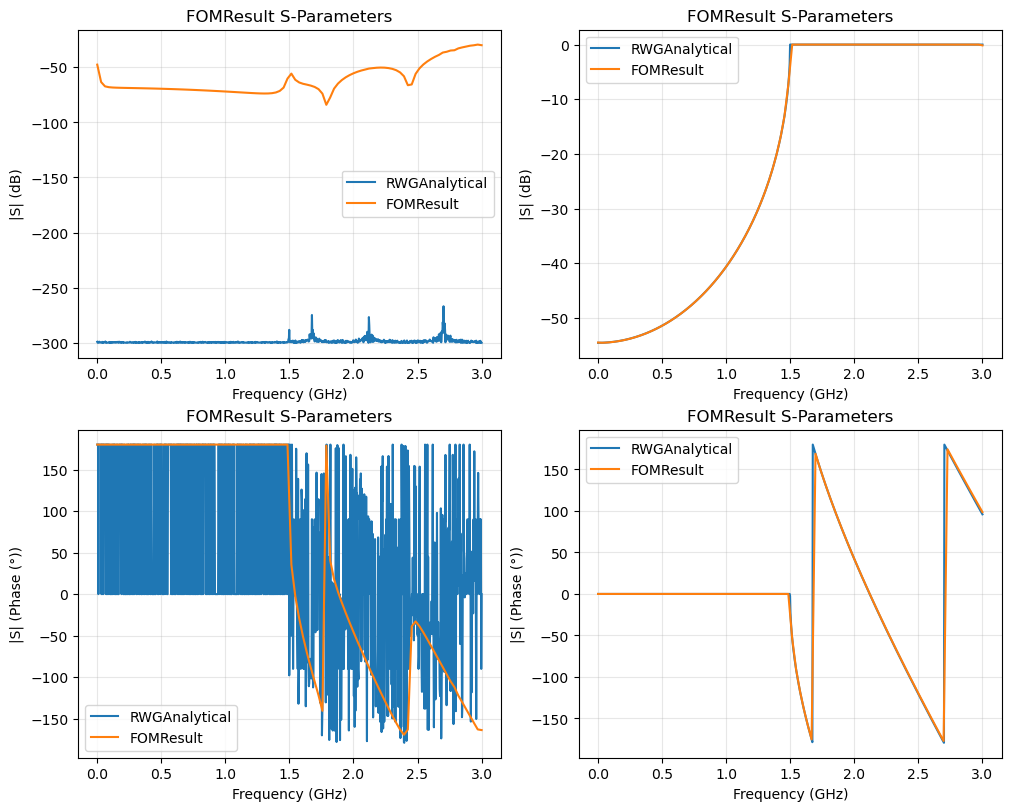

In [6]:
# Get analytic solution for comparison
from analytical.rectangular_waveguide import RWGAnalytical

analytical = RWGAnalytical(a=a, L=L, freq_range=(fom_config['fmin'], fom_config['fmax']))

# plot comparison
which = [['1(1)1(1)'], ['1(1)2(1)']]
fig, axs = plt.subplot_mosaic([[1, 2], [3, 4]], figsize=(10, 8), layout='constrained')
for idx, wh in enumerate(which):
    # plot magnitude
    analytical.plot_s(wh, ax=axs[idx+1])
    proj.fds.fom.plot_s(wh, ax=axs[idx+1])
    # plot phase
    analytical.plot_s(wh, plot_type='phase', ax=axs[idx+3])
    proj.fds.fom.plot_s(wh, plot_type='phase', ax=axs[idx+3])

 # 4. Reduce Order Model

In [7]:
# Reduce model order
rom = proj.fds.fom.reduce()
rom_config = {
    'nportmodes': 3,
    'nsamples': 1000, # <- changed for more frequency samples
    'fmin': 1e-3,
    'fmax': 3,
    'solver_type': 'direct' # <- changed to direct method, faster for smaller matrices
}
rom_result = rom.solve(config=rom_config) # solve reduced order model on more frequency samples


Model Order Reduction
INFO:: 
Domain: vacuum
Total: 1428 → 106 DOFs
Overall compression: 92.6%
  Solve loop: 0.028s (1000 freq points)


In [8]:
proj.fds.fom.K

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 128272 stored elements and shape (1428, 1428)>

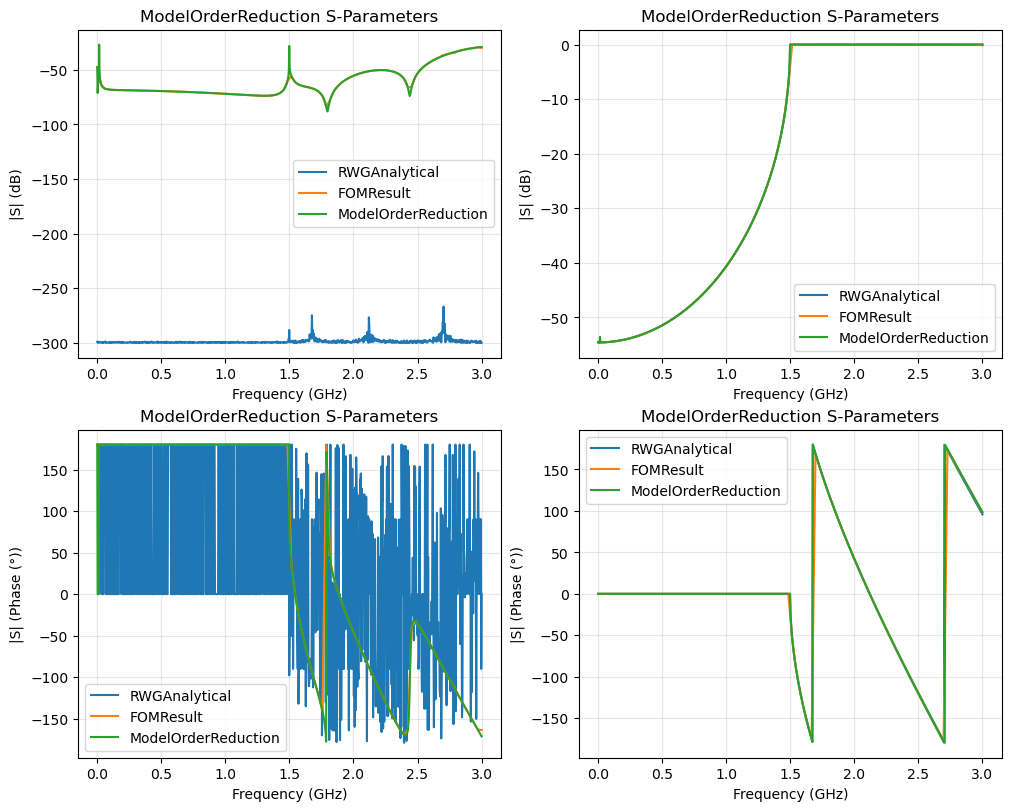

In [9]:
# compare fom, rom and analytical solution
# plot comparison
which = [['1(1)1(1)'], ['1(1)2(1)']]
fig, axs = plt.subplot_mosaic([[1, 2], [3, 4]], figsize=(10, 8), layout='constrained')
for idx, wh in enumerate(which):
    # plot magnitude
    analytical.plot_s(wh, ax=axs[idx+1])
    proj.fds.fom.plot_s(wh, ax=axs[idx+1])
    rom.plot_s(wh, ax=axs[idx+1])
    # plot phase
    analytical.plot_s(wh, plot_type='phase', ax=axs[idx+3])
    proj.fds.fom.plot_s(wh, plot_type='phase', ax=axs[idx+3])
    rom.plot_s(wh, plot_type='phase', ax=axs[idx+3])

# Field visualisation

In [11]:
proj.fds.plot_field(55)


Field visualization at f = 1.6671 GHz
Source: global
Excitation: port1, mode 0
Plotting: |E| (None)


WebGuiWidget(layout=Layout(height='50vh', width='100%'), value={'gui_settings': {'camera': {'euler_angles': [4…